In [2]:
import numpy as np
from scipy.ndimage import laplace, sobel
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from wavefield_computation import setup_model_and_geometry

In [81]:
model, dataset = setup_model_and_geometry(0)
dataset._dt_r = model.critical_dt
dataset._t_max_r = 40.0
dataset.resample_on()

Operator `initdamp` ran in 0.01 s


236.7746
318.8675501751727


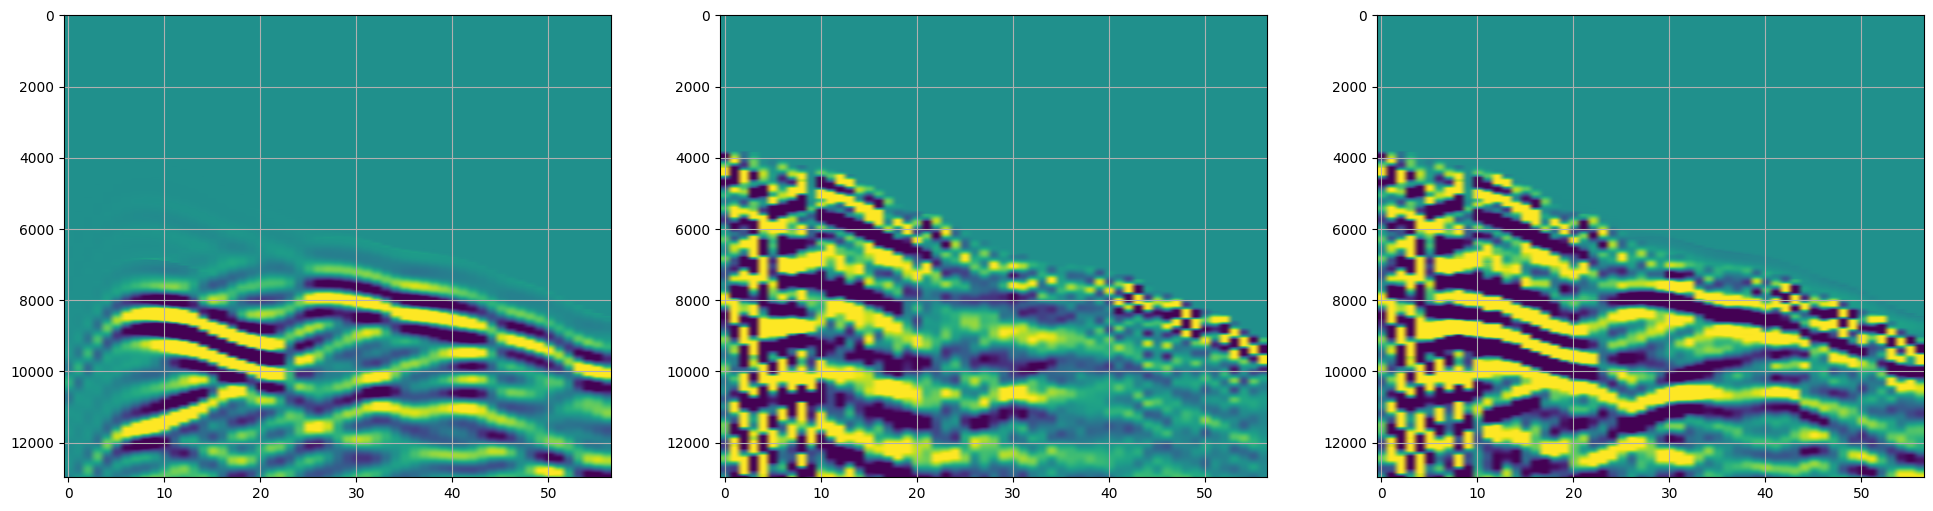

In [97]:
d_obs = dataset[0][0]
born = np.load("adjoint_snaps/recon_gather_1.npy")
qa = np.quantile(d_obs, 0.95)
print(np.linalg.norm(born))
print(np.linalg.norm(d_obs))
fig, axs = plt.subplots(1, 3, figsize=(24, 6))
axs[0].imshow(born, aspect='auto', vmin=-qa, vmax=qa)
axs[1].imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
axs[2].imshow(d_obs.T-born, aspect='auto', vmin=-qa, vmax=qa)
for ax in axs:
    ax.grid()
plt.show()

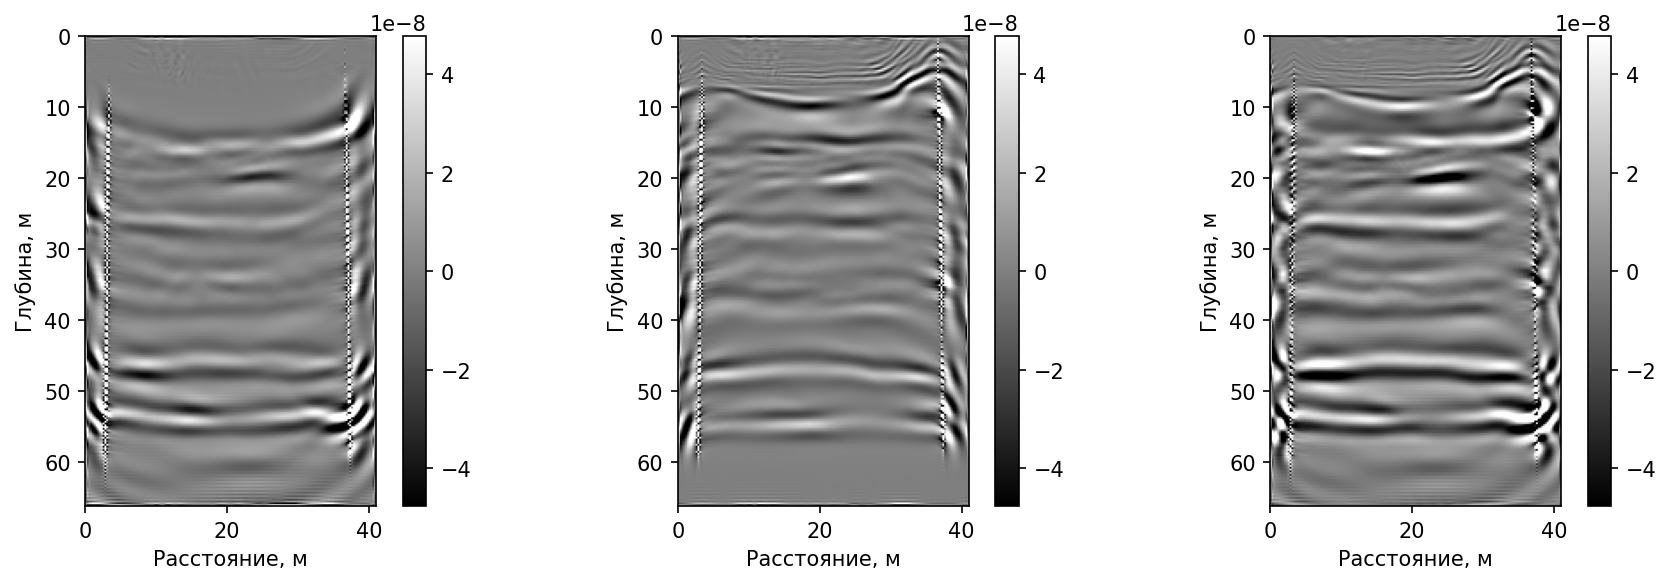

In [39]:
grad_u0 = np.load("gradients/grad_full_u_0.npy")
grad_d0 = np.load("gradients/grad_full_d_0.npy")
# magnitude[magnitude] = np.nan
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=150)
# glmax = max([np.max(np.abs(grad_d)), np.max(np.abs(grad_u))])
glmax = max([np.quantile(grad_d0, 0.99), np.quantile(grad_u0, 0.99)])
imag0 = grad_d0-grad_u0
imag0 = np.load("images/image_iter_0.npy")[::10, ::10]
for gr, ax in zip([grad_d0, grad_u0, imag0], axs):
    # h=ax.imshow(np.diff(gr.T, axis=0, n=2), cmap='gray', vmin=-glmax/5, vmax=glmax/5)
    # h=ax.imshow(np.diff(gr.T, axis=0, n=1), cmap='gray', vmin=-glmax, vmax=glmax)
    h=ax.imshow(laplace(gr.T), cmap='gray', vmin=-glmax/5, vmax=glmax/5, extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])
    # h=ax.imshow(gr.T, cmap='gray', vmin=-glmax/1, vmax=glmax/1, extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

    fig.colorbar(h)



plt.tight_layout()
plt.show()

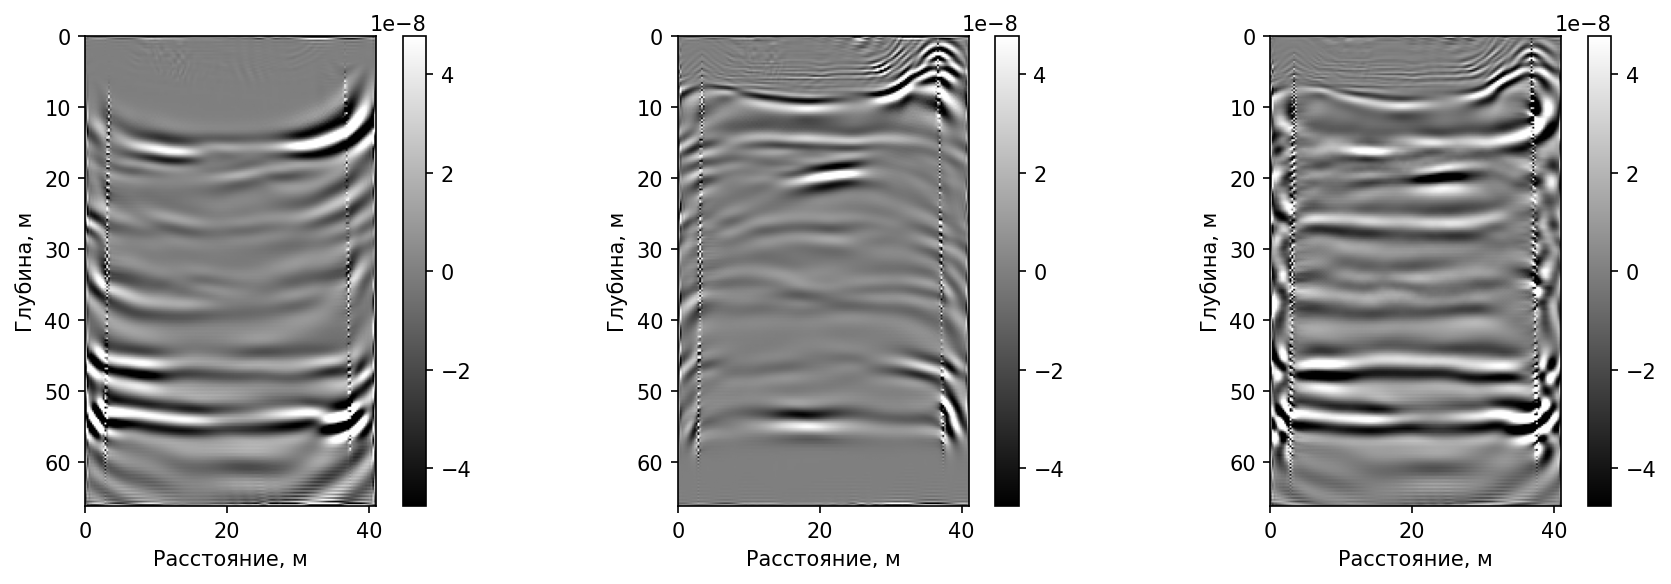

In [40]:
grad_u1 = np.load("gradients/grad_full_u_1.npy")
grad_d1 = np.load("gradients/grad_full_d_1.npy")
# magnitude[magnitude] = np.nan
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=150)
# glmax = max([np.max(np.abs(grad_d)), np.max(np.abs(grad_u))])
# glmax = max([np.quantile(grad_d1, 0.98), np.quantile(grad_u1, 0.98)])
grad1 = grad_d1-grad_u1

# imag1 = imag0 - grad1*0.2
imag1 = np.load("images/image_iter_1.npy")[::10, ::10]
for gr, ax in zip([grad_d1, grad_u1, imag1], axs):
    # h=ax.imshow(np.diff(gr.T, axis=0, n=2), cmap='gray', vmin=-glmax/5, vmax=glmax/5)
    # h=ax.imshow(np.diff(gr.T, axis=0, n=1), cmap='gray', vmin=-glmax/10, vmax=glmax/10)
    h=ax.imshow(laplace(gr.T, ), cmap='gray', vmin=-glmax/5, vmax=glmax/5, extent=[0, grad_d1.shape[0]*0.25, grad_d1.shape[1]*0.25, 0])
    # h=ax.imshow(gr.T, cmap='gray', vmin=-glmax/1, vmax=glmax/1, extent=[0, grad_d1.shape[0]*0.25, grad_d1.shape[1]*0.25, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

    fig.colorbar(h)



plt.tight_layout()
plt.show()

In [ ]:
# from image_update import upsample_image

# def get_model_shape():
#     return 1630, 2640

# grad_upsampled = upsample_image(imag1, *get_model_shape())
# print(grad_upsampled.shape)
# np.save("../lsrtm/images/image_iter_1.npy", grad_upsampled)

(1630, 2640)


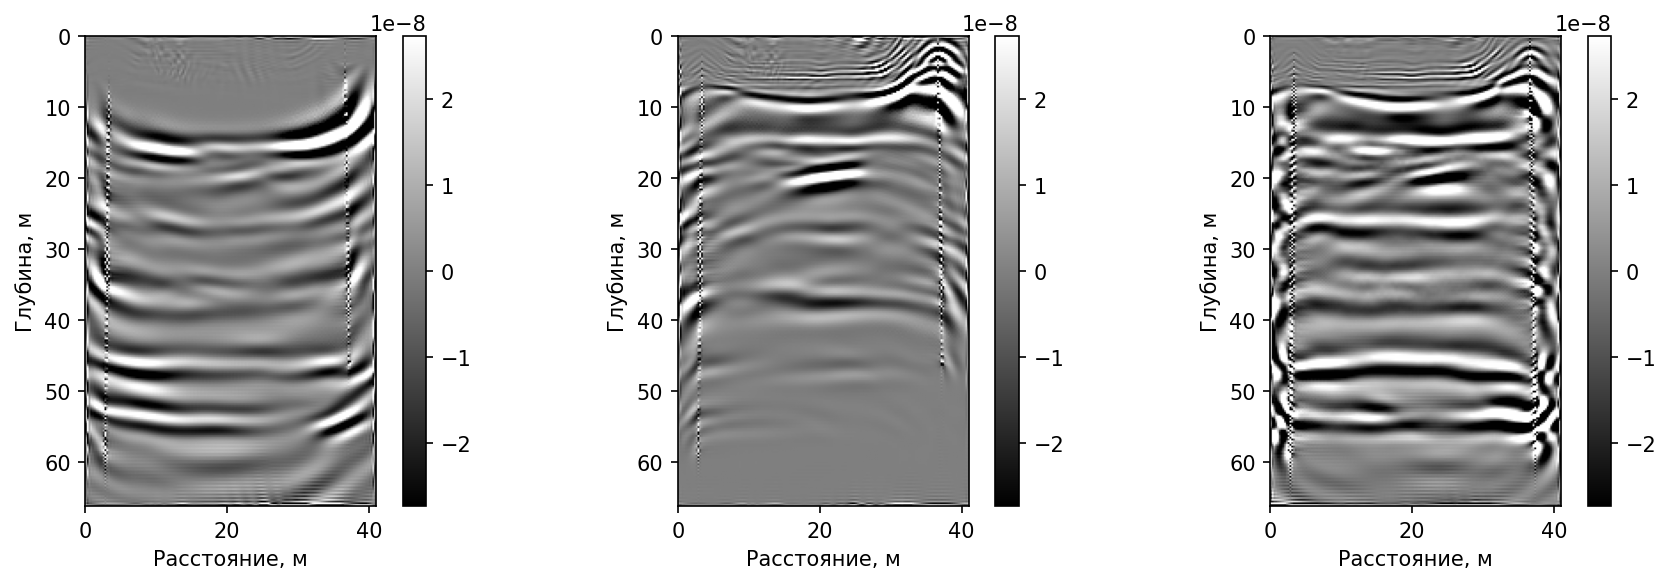

In [196]:
# grad_u2 = np.load("gradients/grad_full_u_2.npy")
# grad_d2 = np.load("gradients/grad_full_d_2.npy")
# magnitude[magnitude] = np.nan
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=150)
# glmax = max([np.max(np.abs(grad_d)), np.max(np.abs(grad_u))])
# glmax = max([np.quantile(grad_d1, 0.98), np.quantile(grad_u1, 0.98)])
grad2 = grad_d2-grad_u2

imag2 = imag1 - grad2*0.2
for gr, ax in zip([grad_d2, grad_u2, imag2], axs):
    # h=ax.imshow(np.diff(gr.T, axis=0, n=2), cmap='gray', vmin=-glmax/5, vmax=glmax/5)
    # h=ax.imshow(np.diff(gr.T, axis=0, n=1), cmap='gray', vmin=-glmax, vmax=glmax)
    h=ax.imshow(laplace(gr.T), cmap='gray', vmin=-glmax/5, vmax=glmax/5, extent=[0, grad_d1.shape[0]*0.25, grad_d1.shape[1]*0.25, 0])
    # h=ax.imshow(gr.T, cmap='gray', vmin=-glmax/1, vmax=glmax/1, extent=[0, grad_d1.shape[0]*0.25, grad_d1.shape[1]*0.25, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

    fig.colorbar(h)



plt.tight_layout()
plt.show()

In [ ]:
from image_update import upsample_image

def get_model_shape():
    return 1630, 2640

grad_upsampled = upsample_image(imag2, *get_model_shape())
print(grad_upsampled.shape)
# np.save("../lsrtm/images/image_iter_2.npy", grad_upsampled)

(1630, 2640)


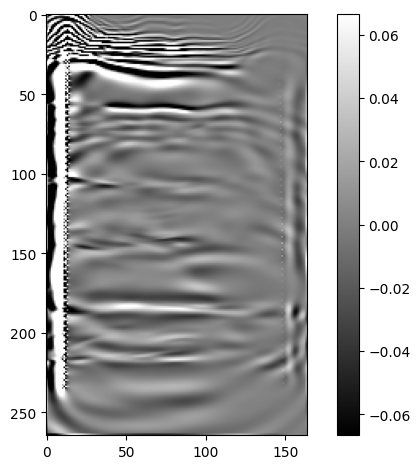

In [91]:
grad1 = np.load("gradients/grad_full_0.npy")
buff = grad1.T*1000
qa = np.quantile(buff, 0.99)
# h=plt.imshow(buff, cmap='gray', vmin=-qa, vmax=qa)
h=plt.imshow(laplace(buff), cmap='gray', vmin=-qa/1e1, vmax=qa/1e1)

plt.colorbar(h)
plt.tight_layout()
plt.show()

In [ ]:

from config import *
import torch
def get_model_shape():
    return 1630, 2640

def get_num_shots():
    return 59
def load_wavefield_snaps_batch(shot_ids, wavefield_type='forward'):
    dir_path = OUTPUT_DIRS['forward_snaps'] if wavefield_type == 'forward' else OUTPUT_DIRS['adjoint_snaps']
    nx, nz = get_model_shape()
    sub_nx = nx // SUBSAMPLING + 1
    sub_nz = nz // SUBSAMPLING + 1
    
    batch = torch.empty((len(shot_ids), NSNAPS, sub_nx, sub_nz),
                    dtype=torch.float32,
                    pin_memory=True)
    
    for i, shot_id in enumerate(shot_ids):
        path = f"{dir_path}/{shot_id+1}.npy"
        batch[i] = torch.from_numpy(np.load(path))  # Copy forces read into memory
    
    return batch

In [99]:
# shot_ids = range(0, get_num_shots(), 10)

from grad_computation import load_wavefield_snaps_batch

shot_ids = range(0, 6)

u0_batch = load_wavefield_snaps_batch(shot_ids, 'forward')
v_batch = load_wavefield_snaps_batch(shot_ids, 'adjoint')

print(u0_batch.numpy().shape)

(6, 500, 164, 265)


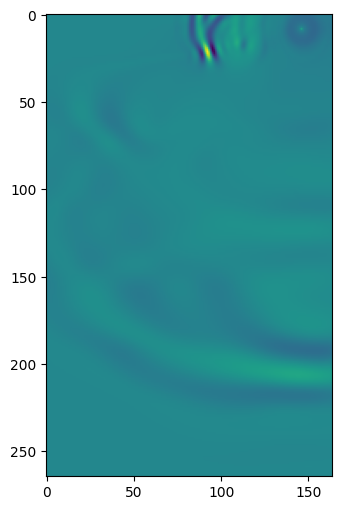

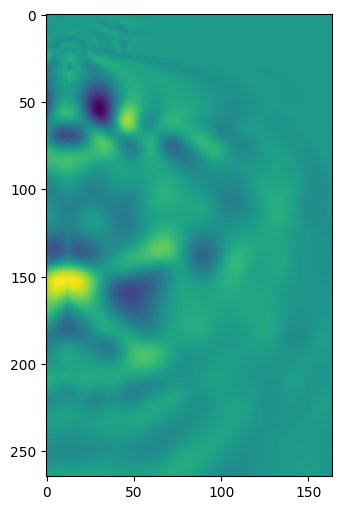

In [105]:
N = 2
K = 300
plt.imshow(u0_batch.numpy()[N][K].T)
plt.show()
plt.imshow(v_batch.numpy()[N][K].T)
plt.show()

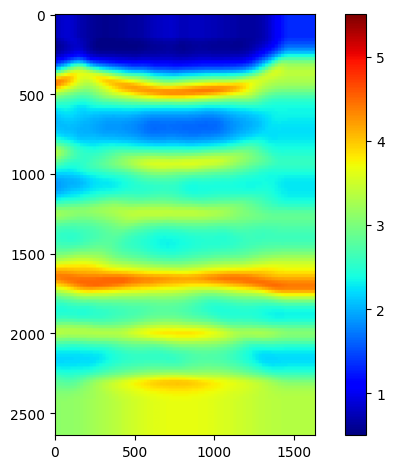

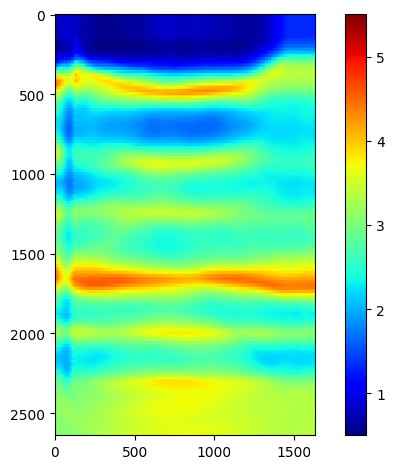

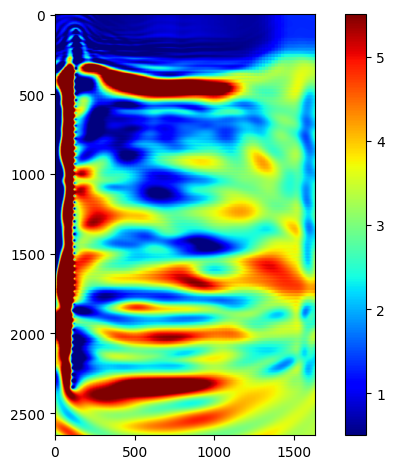

In [66]:
for i in range(0, 3):
    path = f"images/image_iter_{i}.npy"
    grad1 = np.load(path)
    buff = grad1.T
    # h = plt.imshow(buff, cmap='jet', vmin=qa1, vmax=qa2)
    h = plt.imshow(buff, cmap='jet', vmin=0.5, vmax=5.5)
    plt.gcf().colorbar(h)
    plt.tight_layout()
    plt.savefig(f"pngs/_{i}.png")
    plt.show()

In [8]:
from wavefield_computation import setup_model_and_geometry
import numpy as np
model, dataset = setup_model_and_geometry(29)

(1630, 2640)


Operator `initdamp` ran in 0.01 s


In [5]:
from config import *
d_syn = np.load(f"{OUTPUT_DIRS['forward_snaps']}/recon_gather_{20}.npy")
print(d_syn.shape)

(12984, 57)


In [6]:
dataset._dt_r = model.critical_dt
dataset._t_max_r = 40.0
dataset.resample_on()
d_obs = dataset[20][0]
print(d_obs.shape)

(57, 12984)


In [7]:
print(np.quantile(d_obs, 0.99))
print(np.quantile(d_syn, 0.99))
scale_factor = np.sqrt(np.sum(d_obs.ravel()**2))/np.sqrt(np.sum(d_syn.ravel()**2))
print(scale_factor)

3.218513935875701
0.006853265
446.16755457217005


In [9]:

d_obs /= scale_factor

In [11]:
print(np.linalg.norm(d_syn.ravel()))
print(np.linalg.norm(d_obs.ravel()))

2.1409204
2.140921592712403


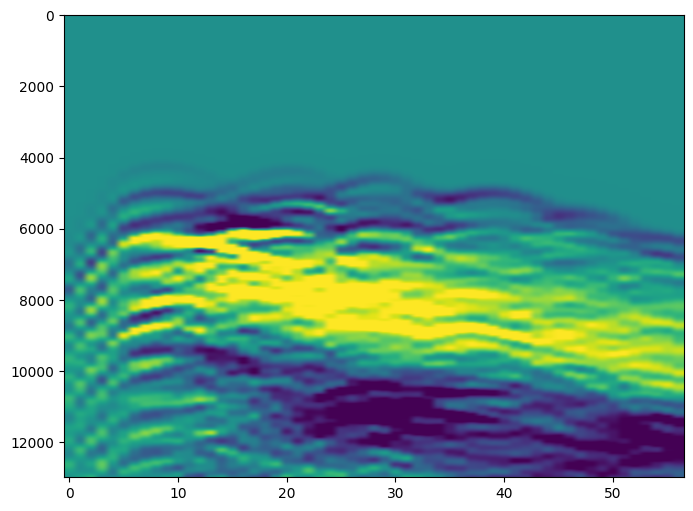

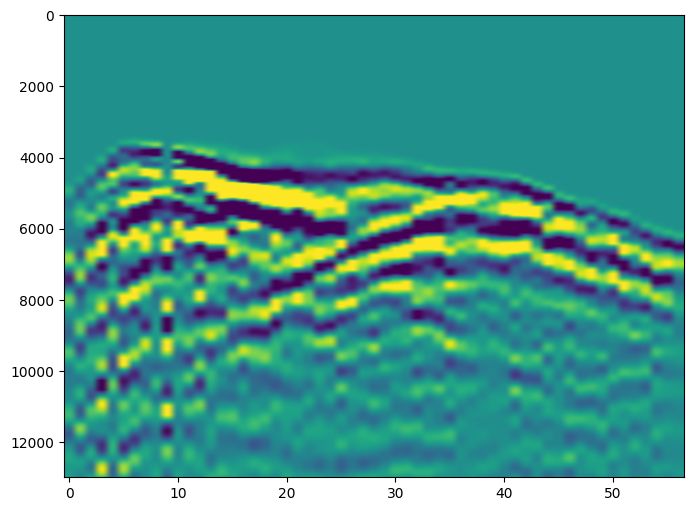

In [10]:
from matplotlib import pyplot as plt
qa = 0.005
plt.imshow(d_syn, aspect='auto', vmin=-qa, vmax=qa)
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.show()